In [15]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [5]:
digits = load_digits()

In [6]:
print(digits.data.shape)
print(digits.target.shape)
print(digits.target[:10])

(1797, 64)
(1797,)
[0 1 2 3 4 5 6 7 8 9]


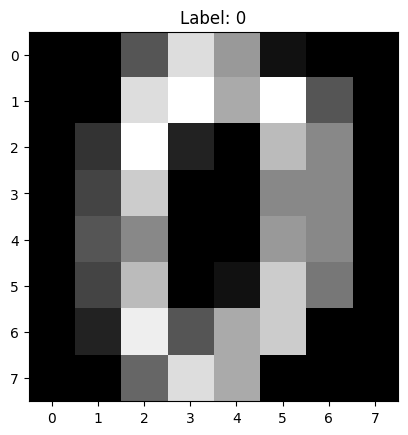

In [8]:
plt.imshow(digits.images[0], cmap='gray')
plt.title(f"Label: {digits.target[0]}")
plt.show()

## PCA

In [10]:
X = digits.data
y = digits.target

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [13]:
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.1%}")

Variance explained: 21.6%


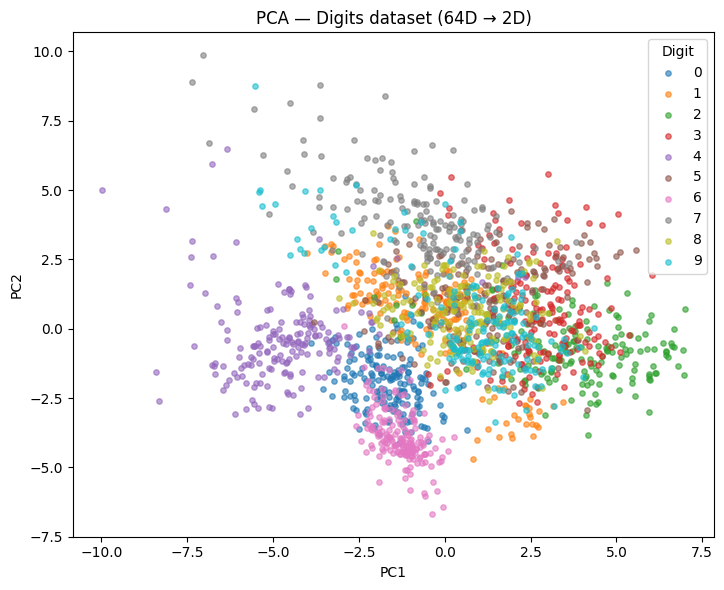

In [14]:
plt.figure(figsize=(8, 6))

for digit in range(10):
    mask = (y == digit)
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=str(digit), alpha=0.6, s=15)

plt.legend(title='Digit', bbox_to_anchor=(1, 1))
plt.title('PCA — Digits dataset (64D → 2D)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

# t-SNE

In [17]:
tsne = TSNE(
    n_components = 2,
    perplexity = 30,
    random_state = 42
)
X_tsne = tsne.fit_transform(X_scaled)

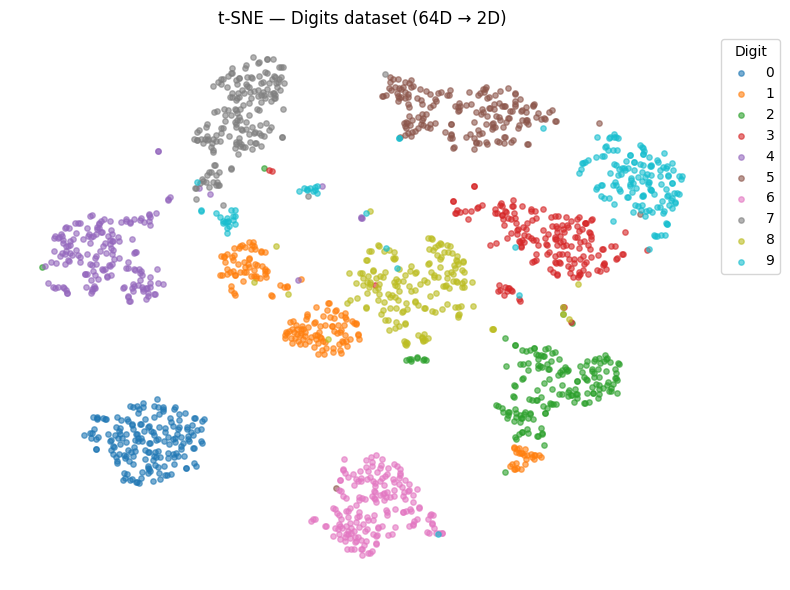

In [18]:
plt.figure(figsize=(8, 6))

for digit in range(10):
    mask = (y == digit)
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                label=str(digit), alpha=0.6, s=15)

plt.legend(title='Digit', bbox_to_anchor=(1, 1))
plt.title('t-SNE — Digits dataset (64D → 2D)')
plt.axis('off')
plt.tight_layout()
plt.show()

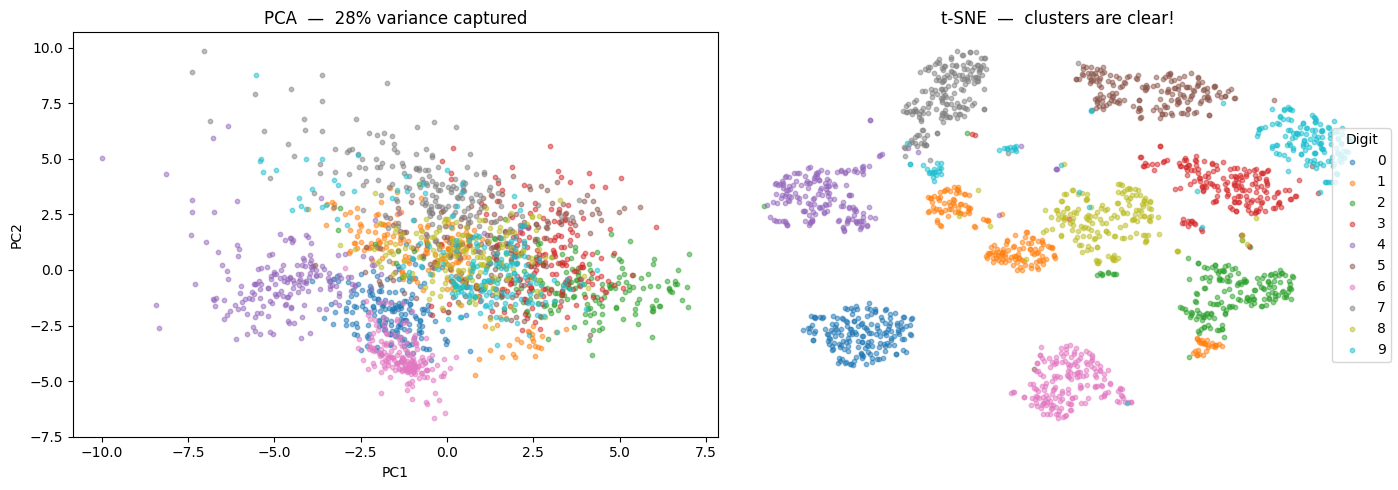

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10.colors 

for digit in range(10):
    mask = (y == digit)
    ax1.scatter(X_pca[mask, 0],  X_pca[mask, 1],
                color=colors[digit], label=str(digit), alpha=0.5, s=10)
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                color=colors[digit], label=str(digit), alpha=0.5, s=10)

ax1.set_title('PCA  —  28% variance captured')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2')

ax2.set_title('t-SNE  —  clusters are clear!')
ax2.axis('off')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='Digit', loc='center right')
plt.tight_layout()
plt.show()